In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification


In [ ]:
folder = "/content/drive/MyDrive/Clean_Shop_Videos"

video_names = np.load(os.path.join(folder,"video_names.npy"), allow_pickle=True)
labels = np.load(os.path.join(folder,"clean_labels.npy"), allow_pickle=True)

video_paths = [os.path.join(folder, name) for name in video_names]

print("videos:", len(video_paths))
print("labels:", len(labels))

videos: 637
labels: 637


In [ ]:
from sklearn.model_selection import train_test_split

train_videos, val_videos, train_labels, val_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

train_videos, test_videos, train_labels, test_labels = train_test_split(
    train_videos,
    train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=42
)

print("Train:", len(train_videos))
print("Validation:", len(val_videos))
print("Test:", len(test_videos))

Train: 432
Validation: 128
Test: 77


In [ ]:
#  Parameters

IMG_SIZE = 224
NUM_FRAMES = 16
EPOCHS = 10
BATCH_SIZE = 2
feature_dir = "/content/drive/MyDrive/features_shop"
os.makedirs(feature_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
!pip install transformers einops

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model.config.num_labels = 2  #  تعديل عدد ال classg 2
model.to(device)


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
    

In [ ]:
from torch.utils.data import DataLoader, Dataset
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, processor, num_frames=16, img_size=224):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames
        self.img_size = img_size

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]

        # 1. استخراج اframes باستخدام OpenCV
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # اختيار الframesبشكل متساوي
        if total_frames <= 0:
            # في حال كان الفيديو تالفاً أو فارغاً
            frames = [np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)] * self.num_frames
        else:
            frame_indices = np.linspace(0, max(total_frames - 1, 0), self.num_frames, dtype=int)
            frames = []
            current_frame = 0
            frame_set = set(frame_indices)

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                if current_frame in frame_set:
                    frame = cv2.resize(frame, (self.img_size, self.img_size))
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frames.append(frame)
                current_frame += 1
            cap.release()

            # تعويض النقص في الإطارات إن وجد
            while len(frames) < self.num_frames:
                frames.append(frames[-1] if frames else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))



        inputs = self.processor(list(frames), return_tensors="pt")

        # 3. إزالة بعد الـ batch الزائد الذي يضيفه الـ processor تلقائياً
        # لأن الـ DataLoader سيقوم بإضافة بعد الـ batch الخاص به لاحقاً
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        return inputs, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = VideoDataset(train_videos, train_labels, processor)
val_dataset   = VideoDataset(val_videos, val_labels, processor)
test_dataset  = VideoDataset(test_videos, test_labels, processor)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [ ]:
#  Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
#  Training loop
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for batch_inputs, batch_labels in tqdm(train_loader):
        batch_inputs = {k:v.to(device) for k,v in batch_inputs.items()}
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad()
        outputs = model(**batch_inputs).logits
        loss = loss_fn(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

100%|██████████| 216/216 [08:53<00:00,  2.47s/it]


Epoch 1/10 - Loss: 0.6650


100%|██████████| 216/216 [06:07<00:00,  1.70s/it]


Epoch 2/10 - Loss: 0.2292


100%|██████████| 216/216 [06:15<00:00,  1.74s/it]


...

Epoch 8/10 - Loss: 0.1260


100%|██████████| 216/216 [06:07<00:00,  1.70s/it]


Epoch 9/10 - Loss: 0.1287


100%|██████████| 216/216 [06:43<00:00,  1.87s/it]

Epoch 10/10 - Loss: 0.1124


🚀 Starting Evaluation Process...


Evaluating: 100%|██████████| 64/64 [02:06<00:00,  1.98s/it]



📊 Classification Report:
              precision    recall  f1-score   support

      Normal     0.8750    0.7778    0.8235        63
       Theft     0.8056    0.8923    0.8467        65

    accuracy                         0.8359       128
   macro avg     0.8403    0.8350    0.8351       128
weighted avg     0.8397    0.8359    0.8353       128



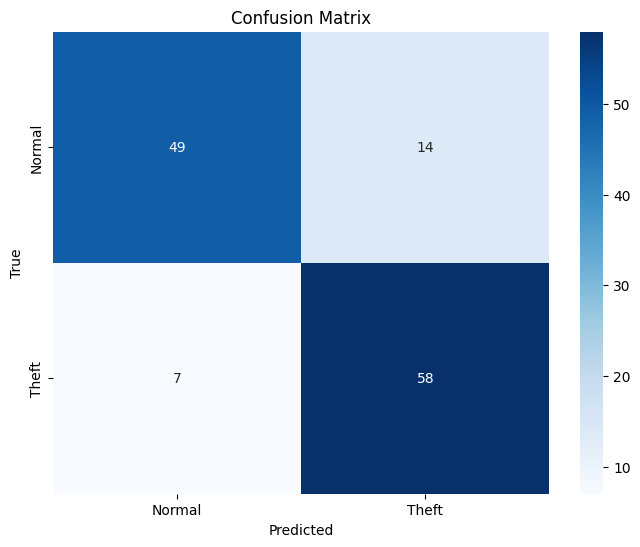

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

#  Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []

print("🚀 Starting Evaluation Process...")

#  Disable gradient calculation for faster inference and memory efficiency
with torch.no_grad():
    # Using val_loader which contains validation data
    for batch_inputs, batch_labels in tqdm(val_loader, desc="Evaluating"):
        # Move inputs to the same device as the model (GPU/CPU)
        batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}

        # Perform inference
        outputs = model(**batch_inputs).logits

        # Get the class with the highest probability
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        # Collect results for final comparison
        all_preds.extend(preds)
        all_labels.extend(batch_labels.numpy())

#  Print Classification Report

print("\n📊 Classification Report:")
target_names = ["Normal", "Theft"]
print(classification_report(all_labels, all_preds, digits=4, target_names=target_names))

#  Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Please upload a video file (.mp4, .avi, etc.):


Saving shop_lifter_n_3_1.mp4 to shop_lifter_n_3_1.mp4
🎬 Processing video: shop_lifter_n_3_1.mp4...
------------------------------
🚀 PREDICTION: Normal
📊 CONFIDENCE: 99.94%
------------------------------


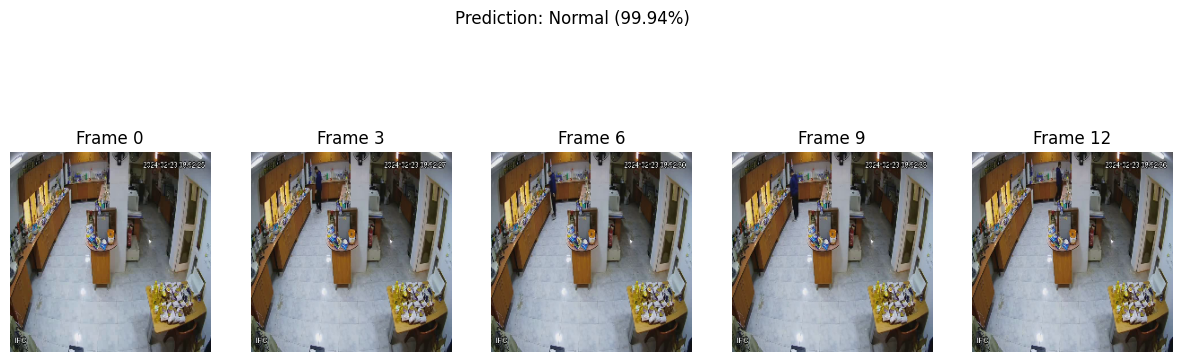

In [ ]:
import cv2
import torch
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

#  Upload the video file
print("Please upload a video file (.mp4, .avi, etc.):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

#  Function to extract frames (same logic as  Dataset)
def extract_frames(path, num_frames=16, img_size=224):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        return [np.zeros((img_size, img_size, 3), dtype=np.uint8)] * num_frames

    indices = np.linspace(0, max(total_frames - 1, 0), num_frames, dtype=int)
    frames = []
    current_frame = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        if current_frame in indices:
            frame = cv2.resize(frame, (img_size, img_size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        current_frame += 1
    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else np.zeros((img_size, img_size, 3), dtype=np.uint8))
    return frames[:num_frames]

#  Process and Predict
model.eval()
print(f"🎬 Processing video: {video_path}...")

# Extract frames
frames = extract_frames(video_path)

# Prepare for model
inputs = processor(list(frames), return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Inference
with torch.no_grad():
    outputs = model(**inputs).logits
    probabilities = torch.softmax(outputs, dim=1)
    prediction_idx = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][prediction_idx].item()

#  Display Results
classes = ["Normal", "Theft"]
result = classes[prediction_idx]

print("-" * 30)
print(f"🚀 PREDICTION: {result}")
print(f"📊 CONFIDENCE: {confidence:.2%}")
print("-" * 30)

# Show a few frames from the video
plt.figure(figsize=(15, 5))
for i in range(5): # Show 5 frames
    plt.subplot(1, 5, i+1)
    plt.imshow(frames[i * 3]) # Pick frames at intervals
    plt.title(f"Frame {i*3}")
    plt.axis('off')
plt.suptitle(f"Prediction: {result} ({confidence:.2%})")
plt.show()


Please upload a video file (.mp4, .avi, etc.):


Saving shop_lifter_6.mp4 to shop_lifter_6.mp4
🎬 Processing video: shop_lifter_6.mp4...
------------------------------
🚀 PREDICTION: Theft
📊 CONFIDENCE: 99.92%
------------------------------


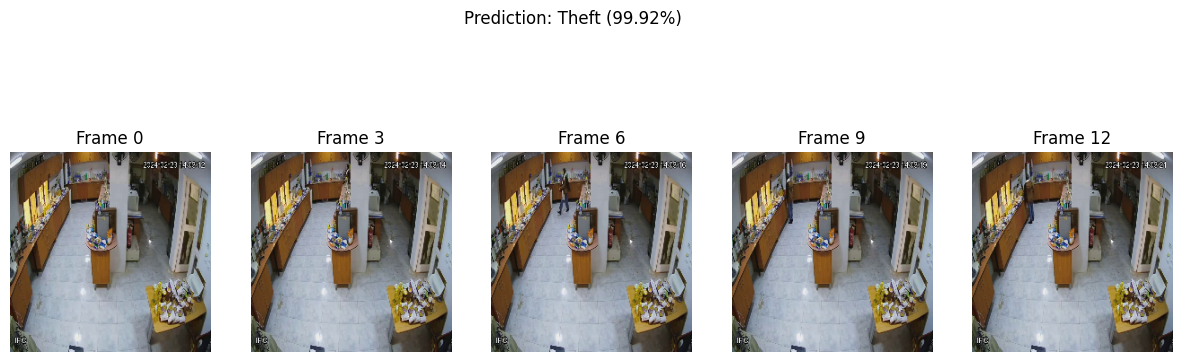

In [ ]:
import cv2
import torch
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

#  Upload the video file
print("Please upload a video file (.mp4, .avi, etc.):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]


#  Process and Predict
model.eval()
print(f"🎬 Processing video: {video_path}...")

# Extract frames
frames = extract_frames(video_path)

# Prepare for model
inputs = processor(list(frames), return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Inference
with torch.no_grad():
    outputs = model(**inputs).logits
    probabilities = torch.softmax(outputs, dim=1)
    prediction_idx = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][prediction_idx].item()

#  Display Results
classes = ["Normal", "Theft"]
result = classes[prediction_idx]

print("-" * 30)
print(f"🚀 PREDICTION: {result}")
print(f"📊 CONFIDENCE: {confidence:.2%}")
print("-" * 30)

# Show a few frames from the video
plt.figure(figsize=(15, 5))
for i in range(5): # Show 5 frames
    plt.subplot(1, 5, i+1)
    plt.imshow(frames[i * 3]) # Pick frames at intervals
    plt.title(f"Frame {i*3}")
    plt.axis('off')
plt.suptitle(f"Prediction: {result} ({confidence:.2%})")
plt.show()


Please upload a video file (.mp4, .avi, etc.):


Saving videyyyyyynnnnnnzzzzzyyyss_6.mp4 to videyyyyyynnnnnnzzzzzyyyss_6.mp4
🎬 Processing video: videyyyyyynnnnnnzzzzzyyyss_6.mp4...
------------------------------
🚀 PREDICTION: Theft
📊 CONFIDENCE: 99.96%
------------------------------


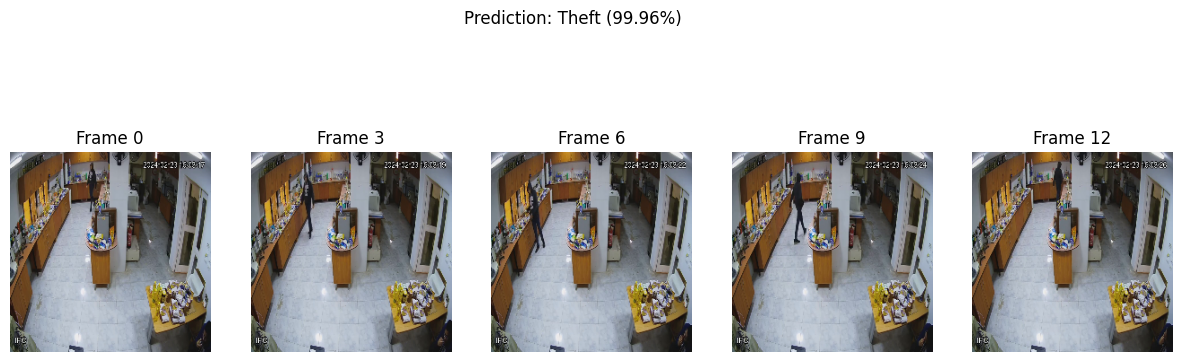

In [ ]:
import cv2
import torch
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

#  Upload the video file
print("Please upload a video file (.mp4, .avi, etc.):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]


#  Process and Predict
model.eval()
print(f"🎬 Processing video: {video_path}...")

# Extract frames
frames = extract_frames(video_path)

# Prepare for model
inputs = processor(list(frames), return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Inference
with torch.no_grad():
    outputs = model(**inputs).logits
    probabilities = torch.softmax(outputs, dim=1)
    prediction_idx = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][prediction_idx].item()

#  Display Results
classes = ["Normal", "Theft"]
result = classes[prediction_idx]

print("-" * 30)
print(f"🚀 PREDICTION: {result}")
print(f"📊 CONFIDENCE: {confidence:.2%}")
print("-" * 30)

# Show a few frames from the video
plt.figure(figsize=(15, 5))
for i in range(5): # Show 5 frames
    plt.subplot(1, 5, i+1)
    plt.imshow(frames[i * 3]) # Pick frames at intervals
    plt.title(f"Frame {i*3}")
    plt.axis('off')
plt.suptitle(f"Prediction: {result} ({confidence:.2%})")
plt.show()
